In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [58]:
import pandas as pd
file_path = "../dataset/E Commerce Dataset.xlsx"

df = pd.read_excel(file_path, sheet_name="E Comm")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [59]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [60]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5630
Number of columns: 20


In [61]:
print("Columns in the dataset:\n")

for column in df.columns:
    print(column)

Columns in the dataset:

CustomerID
Churn
Tenure
PreferredLoginDevice
CityTier
WarehouseToHome
PreferredPaymentMode
Gender
HourSpendOnApp
NumberOfDeviceRegistered
PreferedOrderCat
SatisfactionScore
MaritalStatus
NumberOfAddress
Complain
OrderAmountHikeFromlastYear
CouponUsed
OrderCount
DaySinceLastOrder
CashbackAmount


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

In [64]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [65]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64


In [66]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_table[missing_table["Missing Values"] > 0]

,Missing Values,Percentage
Tenure,264,4.689165
WarehouseToHome,251,4.458259
HourSpendOnApp,255,4.529307
OrderAmountHikeFromlastYear,265,4.706927
CouponUsed,256,4.547069
OrderCount,258,4.582593
DaySinceLastOrder,307,5.452931


In [67]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [68]:
print(df["Churn"].value_counts())

Churn
0    4682
1     948
Name: count, dtype: int64


In [69]:
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64


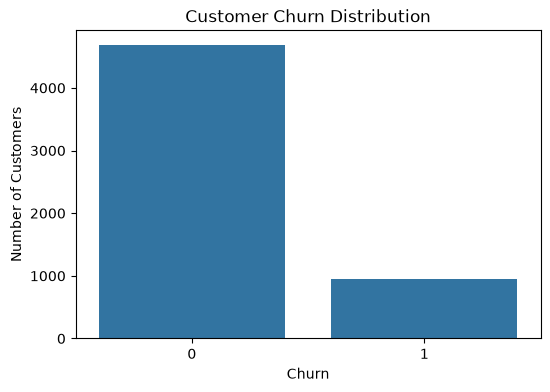

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [71]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(churn_percentage)

Churn Distribution:
Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64


In [72]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Columns:")
print(list(numerical_columns))

Numerical Columns:
['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


In [73]:
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(list(categorical_columns))

Categorical Columns:
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


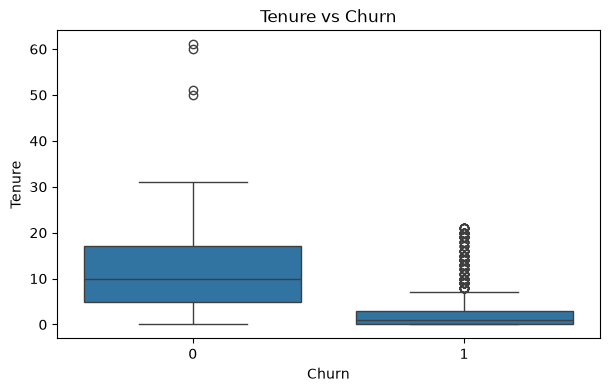

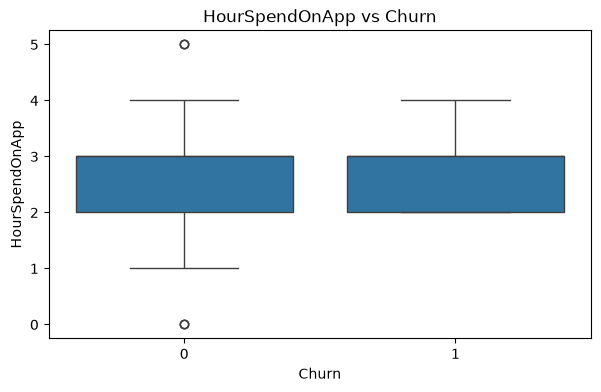

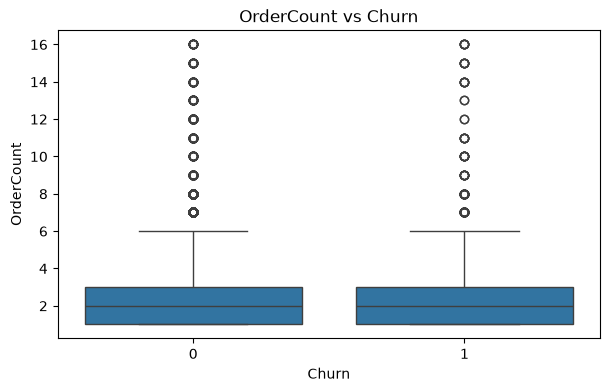

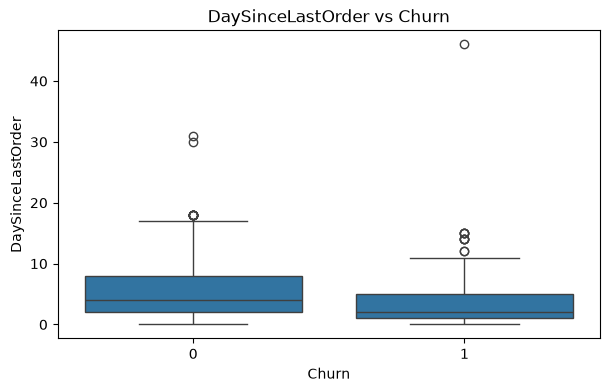

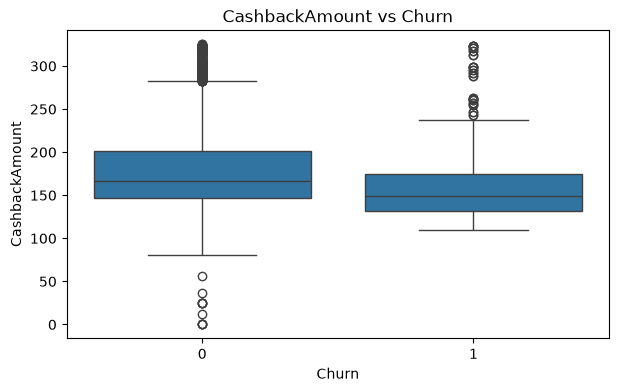

In [74]:
features = [
    "Tenure",
    "HourSpendOnApp",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount"
]

for feature in features:
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(data=df, x="Churn", y=feature)
    
    plt.title(f"{feature} vs Churn")
    plt.show()

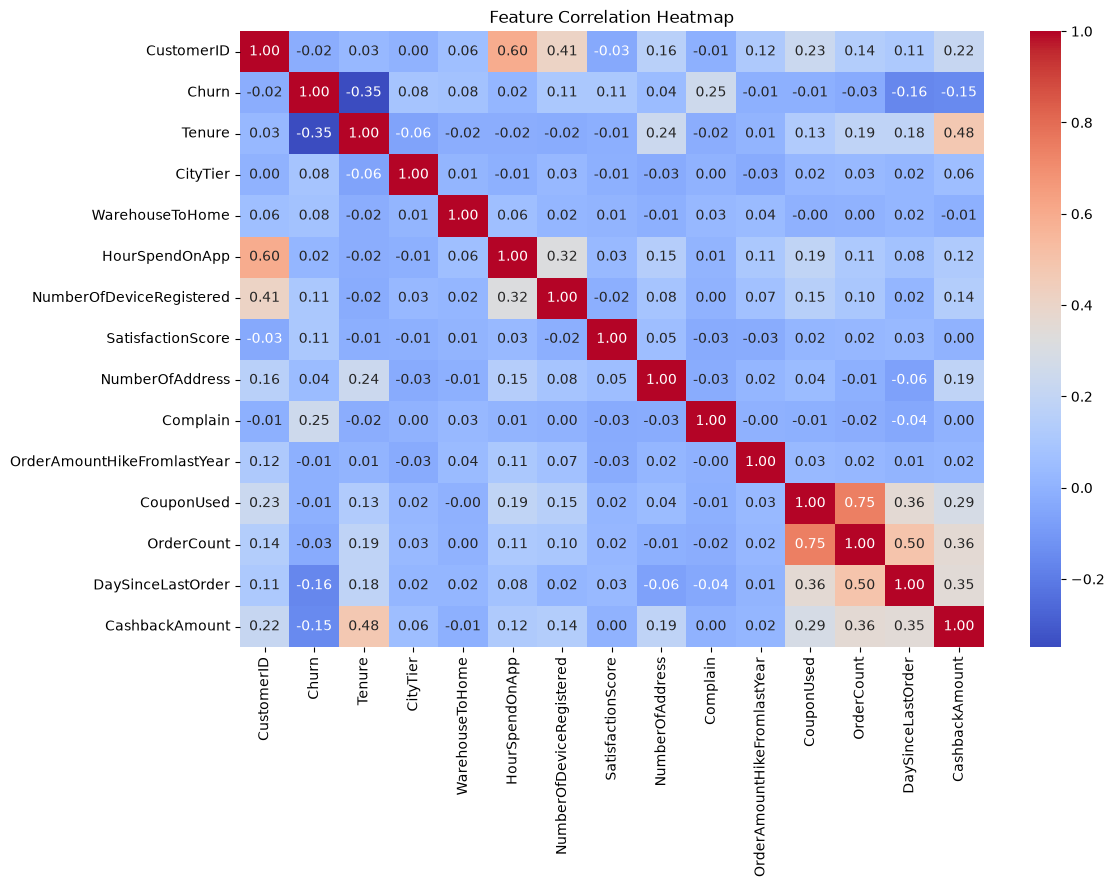

In [75]:
plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [76]:
# Create a copy of the original dataset
data = df.copy()

print("Copy created successfully!")

Copy created successfully!


In [77]:
data = data.drop("CustomerID", axis=1)

print("CustomerID removed")
print(data.shape)

CustomerID removed
(5630, 19)


In [78]:
print("Missing values before handling:\n")
print(data.isnull().sum())

Missing values before handling:

Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


In [79]:
# Separate numerical and categorical columns
numerical_columns = data.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = data.select_dtypes(include=["object"]).columns

# Fill numerical missing values with median
for column in numerical_columns:
    data[column] = data[column].fillna(data[column].median())

# Fill categorical missing values with mode
for column in categorical_columns:
    data[column] = data[column].fillna(data[column].mode()[0])

print("Missing values handled successfully!")

Missing values handled successfully!


In [80]:
print(data.isnull().sum().sum())

0


In [81]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5630, 18)
Target shape: (5630,)


In [82]:
X = pd.get_dummies(X, drop_first=True)

print("Encoding completed!")
print("New feature count:", X.shape[1])

Encoding completed!
New feature count: 29


In [83]:
X.head()

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,4.0,3,6.0,3.0,3,2,9,1,11.0,1.0,...,False,False,False,False,True,False,False,False,False,True
1,9.0,1,8.0,3.0,4,3,7,1,15.0,0.0,...,False,True,True,False,False,True,False,False,False,True
2,9.0,1,30.0,2.0,4,3,6,1,14.0,0.0,...,False,False,True,False,False,True,False,False,False,True
3,0.0,3,15.0,2.0,4,5,8,0,23.0,0.0,...,False,False,True,False,True,False,False,False,False,True
4,0.0,1,12.0,3.0,3,5,3,0,11.0,1.0,...,False,False,True,False,False,True,False,False,False,True


In [84]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4504
Testing samples: 1126


In [85]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("ML models imported successfully!")

ML models imported successfully!


In [87]:
# Start fresh from the original dataset
data = df.copy()

# Remove CustomerID
data = data.drop("CustomerID", axis=1)

# Separate target variable
y = data["Churn"]
X = data.drop("Churn", axis=1)

# Identify numerical and categorical columns
numerical_columns = X.select_dtypes(include=["number"]).columns
categorical_columns = X.select_dtypes(exclude=["number"]).columns

print("Numerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

# Fill missing numerical values with median
for column in numerical_columns:
    X[column] = X[column].fillna(X[column].median())

# Fill missing categorical values with the most frequent value
for column in categorical_columns:
    X[column] = X[column].fillna(X[column].mode()[0])

# Convert categorical columns using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Make sure all columns are numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Final safety check for any remaining NaN values
X = X.fillna(X.median())

print("\nTotal missing values:", X.isnull().sum().sum())
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Numerical columns:
['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

Categorical columns:
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

Total missing values: 0
Feature shape: (5630, 29)
Target shape: (5630,)


In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4504
Testing samples: 1126


In [89]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [90]:
import numpy as np
print("NaN in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("NaN in X_test_scaled:", np.isnan(X_test_scaled).sum())

NaN in X_train_scaled: 0
NaN in X_test_scaled: 0


In [91]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [92]:
y_pred_lr = logistic_model.predict(X_test_scaled)

print("Logistic Regression predictions generated!")

Logistic Regression predictions generated!


In [93]:
print("Logistic Regression Results")
print("=" * 40)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.88898756660746

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       936
           1       0.74      0.52      0.61       190

    accuracy                           0.89      1126
   macro avg       0.83      0.74      0.77      1126
weighted avg       0.88      0.89      0.88      1126



In [94]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [95]:
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest predictions generated!")

Random Forest predictions generated!


In [96]:
print("Random Forest Results")
print("=" * 40)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.9813499111900533

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       936
           1       0.94      0.95      0.95       190

    accuracy                           0.98      1126
   macro avg       0.96      0.97      0.97      1126
weighted avg       0.98      0.98      0.98      1126



In [97]:
from xgboost import XGBClassifier

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [98]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [99]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost predictions generated!")

XGBoost predictions generated!


In [100]:
print("XGBoost Results")
print("=" * 40)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results
Accuracy: 0.9484902309058615

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       936
           1       0.91      0.77      0.83       190

    accuracy                           0.95      1126
   macro avg       0.93      0.88      0.90      1126
weighted avg       0.95      0.95      0.95      1126



In [101]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(
            y_test,
            logistic_model.predict_proba(X_test_scaled)[:, 1]
        ),
        roc_auc_score(
            y_test,
            random_forest_model.predict_proba(X_test)[:, 1]
        ),
        roc_auc_score(
            y_test,
            xgb_model.predict_proba(X_test)[:, 1]
        )
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.888988,0.744361,0.521053,0.613003,0.887286
1,Random Forest,0.981350,0.937824,0.952632,0.945170,0.998057
2,XGBoost,0.948490,0.912500,0.768421,0.834286,0.977429


<Figure size 700x500 with 0 Axes>

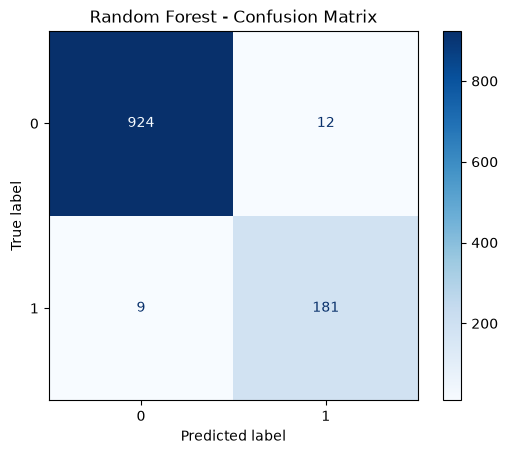

In [102]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

<Figure size 700x500 with 0 Axes>

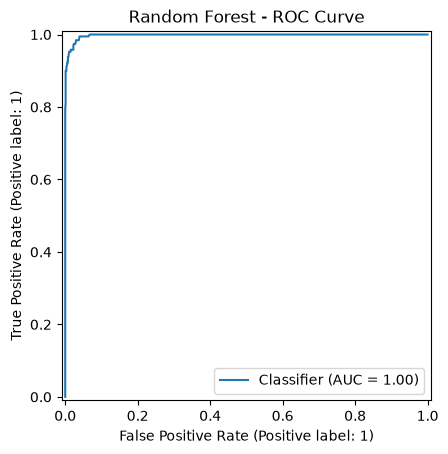

In [103]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    random_forest_model.predict_proba(X_test)[:, 1]
)

plt.title("Random Forest - ROC Curve")
plt.show()

In [104]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,Tenure,0.242951
12,CashbackAmount,0.104624
7,Complain,0.067872
2,WarehouseToHome,0.063961
11,DaySinceLastOrder,0.058506
6,NumberOfAddress,0.053013
8,OrderAmountHikeFromlastYear,0.050751
5,SatisfactionScore,0.049092
4,NumberOfDeviceRegistered,0.031948
10,OrderCount,0.029762


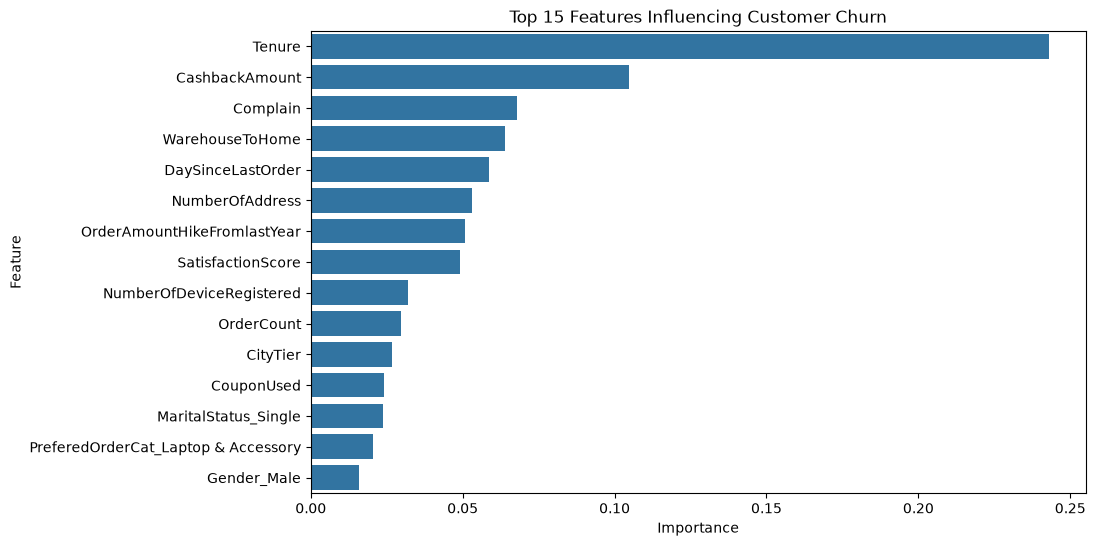

In [105]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Influencing Customer Churn")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [106]:
import joblib
import os

os.makedirs("../model", exist_ok=True)

joblib.dump(
    random_forest_model,
    "../model/random_forest_churn_model.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [107]:
feature_columns = X.columns.tolist()

joblib.dump(
    feature_columns,
    "../model/feature_columns.pkl"
)

print("Feature columns saved successfully!")

Feature columns saved successfully!


In [108]:
joblib.dump(
    scaler,
    "../model/scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [109]:
test_customer = {
    "Tenure": 12,
    "CityTier": 1,
    "WarehouseToHome": 10,
    "HourSpendOnApp": 3,
    "NumberOfDeviceRegistered": 3,
    "SatisfactionScore": 3,
    "NumberOfAddress": 2,
    "Complain": 0,
    "OrderAmountHikeFromlastYear": 15,
    "CouponUsed": 2,
    "OrderCount": 5,
    "DaySinceLastOrder": 3,
    "CashbackAmount": 150,
    "PreferredLoginDevice": "Mobile Phone",
    "PreferredPaymentMode": "Debit Card",
    "Gender": "Male",
    "PreferedOrderCat": "Laptop & Accessory",
    "MaritalStatus": "Married"
}

test_df = pd.DataFrame([test_customer])

test_df

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
0,12,1,10,3,3,3,2,0,15,2,5,3,150,Mobile Phone,Debit Card,Male,Laptop & Accessory,Married


In [110]:
test_encoded = pd.get_dummies(test_df, drop_first=True)

test_encoded = test_encoded.reindex(
    columns=feature_columns,
    fill_value=0
)

test_encoded

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,12,1,10,3,3,3,2,0,15,2,...,0,0,0,0,0,0,0,0,0,0


In [111]:
prediction = random_forest_model.predict(test_encoded)[0]

probability = random_forest_model.predict_proba(test_encoded)[0][1]

print("Prediction:", prediction)
print("Churn Probability:", round(probability * 100, 2), "%")

Prediction: 0
Churn Probability: 0.5 %


In [112]:
if prediction == 1:
    print("⚠️ HIGH CHURN RISK")
    print(f"Probability of churn: {probability * 100:.2f}%")
else:
    print("✅ LOW CHURN RISK")
    print(f"Probability of churn: {probability * 100:.2f}%")

✅ LOW CHURN RISK
Probability of churn: 0.50%
